In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv('civic_complaints_data.csv')

# 1. Display the first 5 rows to understand the structure
display(df.head())

# 2. Check basic information (data types, non-null counts)
print("\n--- Dataset Information ---")
df.info()

# 3. Check for any missing values
print("\n--- Missing Values Count ---")
print(df.isnull().sum())

,Complaint_ID,Category,Area,Priority,Status,Filing_Date,Resolution_Date
0,CMPL-10000,Street Light,Indra Nagar,High,In-Progress,2025-11-28,NaN
1,CMPL-10001,Sewerage,Basharatpur,Medium,Resolved,2024-10-26,2024-12-17
2,CMPL-10002,Street Light,Civil Lines,Low,Pending,2025-06-07,NaN
3,CMPL-10003,Road Construction,Civil Lines,Low,Resolved,2025-03-20,2025-06-26
4,CMPL-10004,Garbage Collection,Civil Lines,Low,In-Progress,2024-07-24,NaN



--- Dataset Information ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Complaint_ID     50000 non-null  object
 1   Category         50000 non-null  object
 2   Area             50000 non-null  object
 3   Priority         50000 non-null  object
 4   Status           50000 non-null  object
 5   Filing_Date      50000 non-null  object
 6   Resolution_Date  16727 non-null  object
dtypes: object(7)
memory usage: 2.7+ MB

--- Missing Values Count ---
Complaint_ID           0
Category               0
Area                   0
Priority               0
Status                 0
Filing_Date            0
Resolution_Date    33273
dtype: int64


C:\Users\Vaibhav Mishra\AppData\Local\Temp\ipykernel_5784\3871067418.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Status', ax=axes[0], palette='viridis')
C:\Users\Vaibhav Mishra\AppData\Local\Temp\ipykernel_5784\3871067418.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y='Category', ax=axes[1], order=df['Category'].value_counts().index, palette='mako')
C:\Users\Vaibhav Mishra\AppData\Local\Temp\ipykernel_5784\3871067418.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y='Area', ax=axes[2]

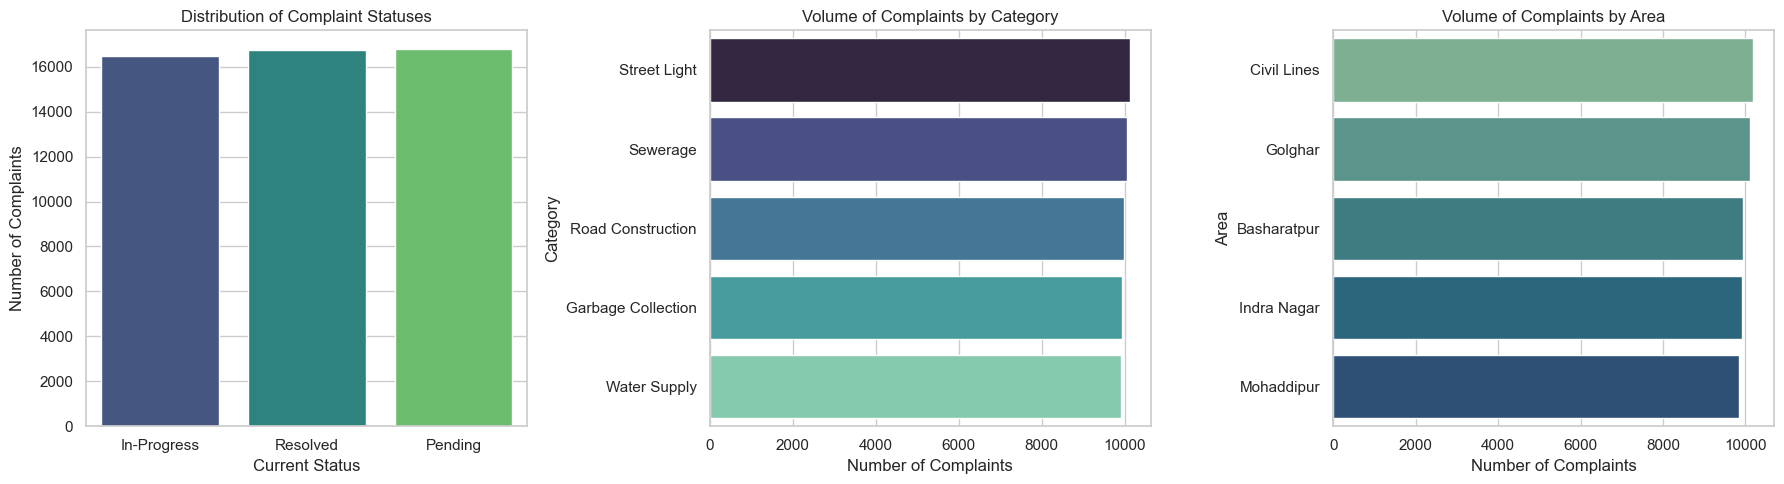

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the visual style for professional-looking plots
sns.set_theme(style="whitegrid")

# Create a figure with 3 subplots (1 row, 3 columns)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Distribution of Complaint Statuses
sns.countplot(data=df, x='Status', ax=axes[0], palette='viridis')
axes[0].set_title('Distribution of Complaint Statuses')
axes[0].set_xlabel('Current Status')
axes[0].set_ylabel('Number of Complaints')

# Plot 2: Complaints by Category
# Using 'order' to sort bars from highest to lowest
sns.countplot(data=df, y='Category', ax=axes[1], order=df['Category'].value_counts().index, palette='mako')
axes[1].set_title('Volume of Complaints by Category')
axes[1].set_xlabel('Number of Complaints')
axes[1].set_ylabel('Category')

# Plot 3: Complaints by Area
sns.countplot(data=df, y='Area', ax=axes[2], order=df['Area'].value_counts().index, palette='crest')
axes[2].set_title('Volume of Complaints by Area')
axes[2].set_xlabel('Number of Complaints')
axes[2].set_ylabel('Area')

# Adjust layout to prevent overlapping text
plt.tight_layout()
plt.show()

In [3]:
# 1. Convert text dates to actual Pandas Datetime objects
df['Filing_Date'] = pd.to_datetime(df['Filing_Date'])
df['Resolution_Date'] = pd.to_datetime(df['Resolution_Date'])

# 2. Calculate the difference in days to create a new feature 'Delay_Days'
# (Note: For Pending/In-Progress, this will automatically become NaN which is fine)
df['Delay_Days'] = (df['Resolution_Date'] - df['Filing_Date']).dt.days

# 3. Let's see the average delay for each complaint category
print("\n--- Average Delay by Category (in Days) ---")
avg_delay = df.groupby('Category')['Delay_Days'].mean().round(1).sort_values(ascending=False)
display(avg_delay)

# 4. Save this updated dataset for the Machine Learning phase tomorrow
df.to_csv('civic_complaints_data_featured.csv', index=False)
print("\nNew dataset saved with Delay_Days feature!")


--- Average Delay by Category (in Days) ---


Category
Road Construction     105.3
Water Supply           32.6
Garbage Collection     32.2
Sewerage               32.2
Street Light            8.0
Name: Delay_Days, dtype: float64


New dataset saved with Delay_Days feature!
